# Proyek Akhir: Menyelesaikan Permasalahan Perusahaan Edutech

- Nama: Alvino Dienova
- Email: alvinodien@yahoo.co.id
- Id Dicoding: dienoov

## Persiapan

### Menyiapkan library yang dibutuhkan

In [131]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split, RandomizedSearchCV
import joblib
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix

### Menyiapkan data yang akan diguankan

In [70]:
df = pd.read_csv('https://raw.githubusercontent.com/dicodingacademy/dicoding_dataset/refs/heads/main/students_performance/data.csv', sep=';')

## Data Understanding

### Ringkasan data

In [71]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Marital_status                                4424 non-null   int64  
 1   Application_mode                              4424 non-null   int64  
 2   Application_order                             4424 non-null   int64  
 3   Course                                        4424 non-null   int64  
 4   Daytime_evening_attendance                    4424 non-null   int64  
 5   Previous_qualification                        4424 non-null   int64  
 6   Previous_qualification_grade                  4424 non-null   float64
 7   Nacionality                                   4424 non-null   int64  
 8   Mothers_qualification                         4424 non-null   int64  
 9   Fathers_qualification                         4424 non-null   i

In [72]:
pd.set_option('display.max_columns', None)
df.head()

,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,Mothers_occupation,Fathers_occupation,Admission_grade,Displaced,Educational_special_needs,Debtor,Tuition_fees_up_to_date,Gender,Scholarship_holder,Age_at_enrollment,International,Curricular_units_1st_sem_credited,Curricular_units_1st_sem_enrolled,Curricular_units_1st_sem_evaluations,Curricular_units_1st_sem_approved,Curricular_units_1st_sem_grade,Curricular_units_1st_sem_without_evaluations,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status
0,1,17,5,171,1,1,122.0,1,19,12,5,9,127.3,1,0,0,1,1,0,20,0,0,0,0,0,0.000000,0,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,3,3,142.5,1,0,0,0,1,0,19,0,0,6,6,6,14.000000,0,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,9,9,124.8,1,0,0,0,1,0,19,0,0,6,0,0,0.000000,0,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,5,3,119.6,1,0,0,1,0,0,20,0,0,6,8,6,13.428571,0,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,9,9,141.5,0,0,0,1,0,0,45,0,0,6,9,5,12.333333,0,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


### Kamus kolom

| Kolom | Tipe | Deskripsi |
| --- | --- | --- |
| Marital_status | Kategori | Status pernikahan |
| Application_mode | Kategori | Jalur pendaftaran |
| Application_order | Numerik | Urutan pilihan program studi saat mendaftar |
| Course | Kategori | Kode program studi yang dipilih |
| Daytime_evening_attendance | Biner | 1 = Daytime, 0 = Evening |
| Previous_qualification | Kategori | Jenis kualifikasi pendidikan sebelumnya |
| Previous_qualification_grade | Numerik | Nilai kualifikasi sebelumnya |
| Nacionality | Kategori | Kewarganegaraan mahasiswa |
| Mothers_qualification | Kategori | Tingkat pendidikan ibu |
| Fathers_qualification | Kategori | Tingkat pendidikan ayah |
| Mothers_occupation | Kategori | Pekerjaan ibu |
| Fathers_occupation | Kategori | Pekerjaan ayah |
| Admission_grade | Numerik | Nilai penerimaan |
| Displaced | Biner | 1 = mahasiswa pindahan |
| Educational_special_needs | Biner | 1 = kebutuhan pendidikan khusus |
| Debtor | Biner | 1 = memiliki utang |
| Tuition_fees_up_to_date | Biner | 1 = UKT lunas |
| Gender | Biner | 0 = Female, 1 = Male |
| Scholarship_holder | Biner | 1 = penerima beasiswa |
| Age_at_enrollment | Numerik | Usia saat mendaftar |
| International | Biner | 1 = mahasiswa internasional |
| Curricular_units_1st_sem_credited | Numerik | SKS yang dikreditkan semester 1 |
| Curricular_units_1st_sem_enrolled | Numerik | SKS yang diambil semester 1 |
| Curricular_units_1st_sem_evaluations | Numerik | Jumlah evaluasi semester 1 |
| Curricular_units_1st_sem_approved | Numerik | SKS lulus semester 1 |
| Curricular_units_1st_sem_grade | Numerik | Nilai rata-rata semester 1 |
| Curricular_units_1st_sem_without_evaluations | Numerik | SKS tanpa evaluasi semester 1 |
| Curricular_units_2nd_sem_credited | Numerik | SKS yang dikreditkan semester 2 |
| Curricular_units_2nd_sem_enrolled | Numerik | SKS yang diambil semester 2 |
| Curricular_units_2nd_sem_evaluations | Numerik | Jumlah evaluasi semester 2 |
| Curricular_units_2nd_sem_approved | Numerik | SKS lulus semester 2 |
| Curricular_units_2nd_sem_grade | Numerik | Nilai rata-rata semester 2 |
| Curricular_units_2nd_sem_without_evaluations | Numerik | SKS tanpa evaluasi semester 2 |
| Unemployment_rate | Numerik | Tingkat pengangguran saat mahasiswa mendaftar |
| Inflation_rate | Numerik | Tingkat inflasi |
| GDP | Numerik | Pertumbuhan GDP |
| Status | Kategori | Graduate / Dropout / Enrolled |

### Exploratory Data Analysis

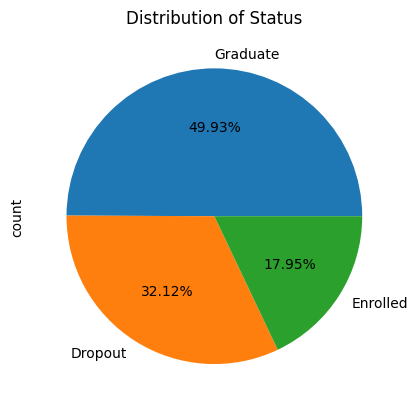

In [73]:
df['Status'].value_counts().plot(kind='pie', autopct='%.2f%%')
plt.title('Distribution of Status')
plt.show()

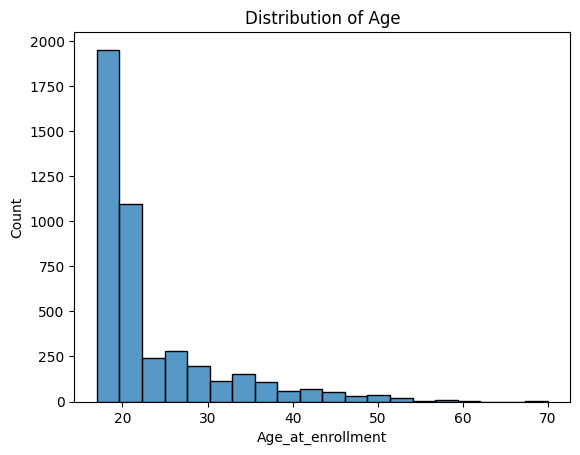

In [74]:
sns.histplot(df['Age_at_enrollment'], bins=20)
plt.title('Distribution of Age')
plt.show()

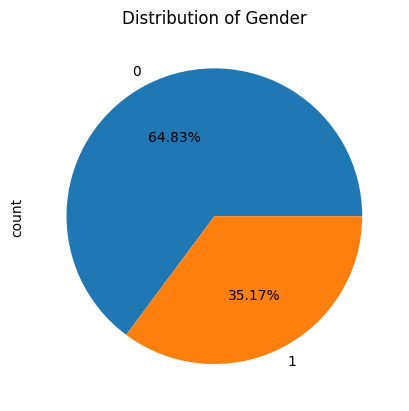

In [75]:
df['Gender'].value_counts().plot(kind='pie', autopct='%.2f%%')
plt.title('Distribution of Gender')
plt.show()

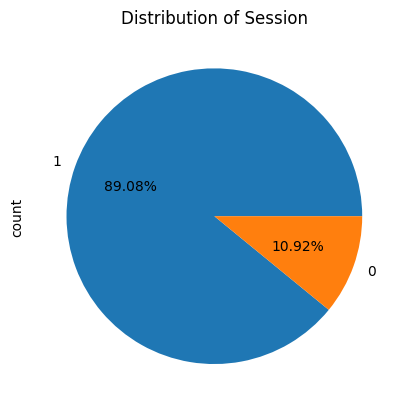

In [76]:
df['Daytime_evening_attendance'].value_counts().plot(kind='pie', autopct='%.2f%%')
plt.title('Distribution of Session')
plt.show()

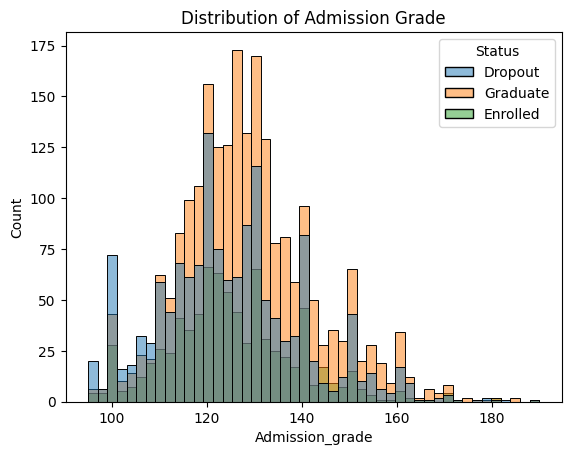

In [96]:
sns.histplot(x='Admission_grade', hue='Status', data=df)
plt.title('Distribution of Admission Grade')
plt.show()

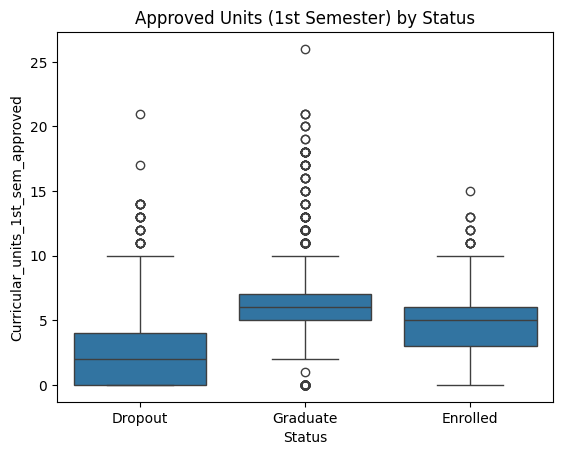

In [78]:
sns.boxplot(x='Status', y='Curricular_units_1st_sem_approved', data=df)
plt.title('Approved Units (1st Semester) by Status')
plt.show()

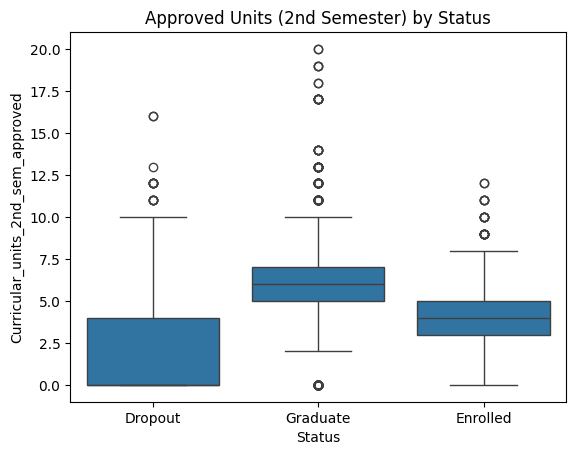

In [79]:
sns.boxplot(x='Status', y='Curricular_units_2nd_sem_approved', data=df)
plt.title('Approved Units (2nd Semester) by Status')
plt.show()

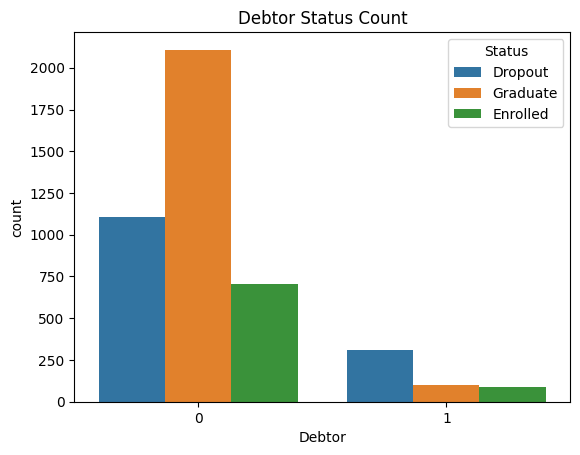

In [80]:
sns.countplot(x='Debtor', hue='Status', data=df)
plt.title('Debtor Status Count')
plt.show()

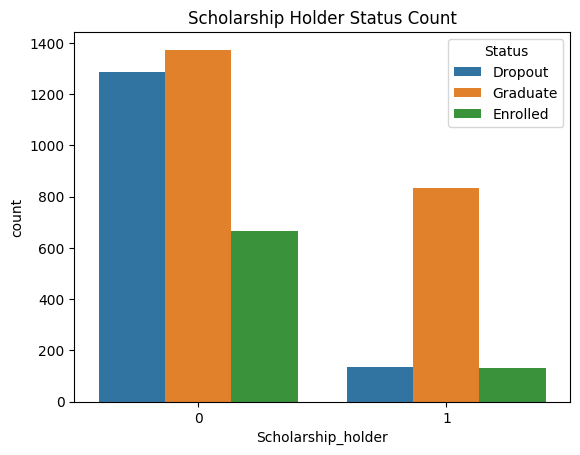

In [98]:
sns.countplot(x='Scholarship_holder', hue='Status', data=df)
plt.title('Scholarship Holder Status Count')
plt.show()

## Data Preparation / Preprocessing

### Data Cleansing

In [81]:
df.isna().sum()

,0
Marital_status,0
Application_mode,0
Application_order,0
Course,0
Daytime_evening_attendance,0
Previous_qualification,0
Previous_qualification_grade,0
Nacionality,0
Mothers_qualification,0
Fathers_qualification,0


In [82]:
df.duplicated().sum()

np.int64(0)

Tidak ada missing value maupun baris duplikat

### Feature Engineering

Tingkat kelulusan SKS semester 1 dan 2

In [83]:
df['Approval_rate_1st_sem'] = np.where(
    df['Curricular_units_1st_sem_enrolled'] > 0,
    df['Curricular_units_1st_sem_approved'] / df['Curricular_units_1st_sem_enrolled'],
    0
)
df['Approval_rate_2nd_sem'] = np.where(
    df['Curricular_units_2nd_sem_enrolled'] > 0,
    df['Curricular_units_2nd_sem_approved'] / df['Curricular_units_2nd_sem_enrolled'],
    0
)

Total SKS lulus kedua semester

In [84]:
df['Total_approved'] = (
    df['Curricular_units_1st_sem_approved'] + df['Curricular_units_2nd_sem_approved']
)

Selisih SKS lulus antar semester

In [85]:
df['Approved_trend'] = df['Curricular_units_2nd_sem_approved'] - df['Curricular_units_1st_sem_approved']

Total SKS diambil kedua semester

In [86]:
df['Total_enrolled'] = (
    df['Curricular_units_1st_sem_enrolled'] + df['Curricular_units_2nd_sem_enrolled']
)

Tingkat kelulusan kumulatif

In [87]:
df['Cumulative_approval_rate'] = np.where(
    df['Total_enrolled'] > 0,
    df['Total_approved'] / df['Total_enrolled'],
    0
)

Nilai rata-rata gabungan kedua semester

In [88]:
df['Avg_grade'] = (
    df['Curricular_units_1st_sem_grade'] + df['Curricular_units_2nd_sem_grade']
) / 2

Selisih nilai antara semester 2 dan semester 1

In [89]:
df['Grade_trend'] = df['Curricular_units_2nd_sem_grade'] - df['Curricular_units_1st_sem_grade']

Indeks rata-rata pendidikan orang tua

In [90]:
df['Parents_education_avg'] = (
    df['Mothers_qualification'] + df['Fathers_qualification']
) / 2

Kondisi ekonomi buruk saat mendaftar

In [91]:
df['Bad_economy'] = (
    (df['Unemployment_rate'] > df['Unemployment_rate'].median()) &
    (df['GDP'] < 0)
).astype(int)

### Export

In [92]:
df.to_csv('students_performance.csv', index=False)

### Label Encoding

In [103]:
le = LabelEncoder()
df['Status'] = le.fit_transform(df['Status'])

### Oversampling

In [120]:
smote = SMOTE(random_state=42)
X, y = smote.fit_resample(df.drop(columns=['Status']), df['Status'])

### Data Splitting

In [121]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

## Modeling

In [126]:
xgb = XGBClassifier(random_state=42)
param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 4, 5],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 0.9, 1.0],
    'colsample_bytree': [0.8, 0.9, 1.0],
    'gamma': [0, 0.1, 0.2]
}
random_search = RandomizedSearchCV(xgb, param_distributions=param_dist, n_iter=10, cv=5, scoring='accuracy', random_state=42)
random_search.fit(X_train, y_train)
xgb = random_search.best_estimator_

### Export

In [132]:
joblib.dump(xgb, 'xgb.joblib')

['xgb.joblib']

## Evaluation

In [127]:
y_pred = xgb.predict(X_test)

### Classification report

In [128]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.87      0.81      0.84       442
           1       0.81      0.79      0.80       442
           2       0.81      0.89      0.85       442

    accuracy                           0.83      1326
   macro avg       0.83      0.83      0.83      1326
weighted avg       0.83      0.83      0.83      1326



### Confusion matrix

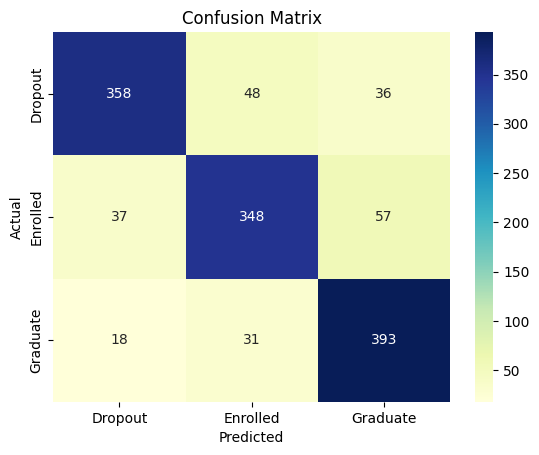

In [129]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='YlGnBu',
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

### Feature importances

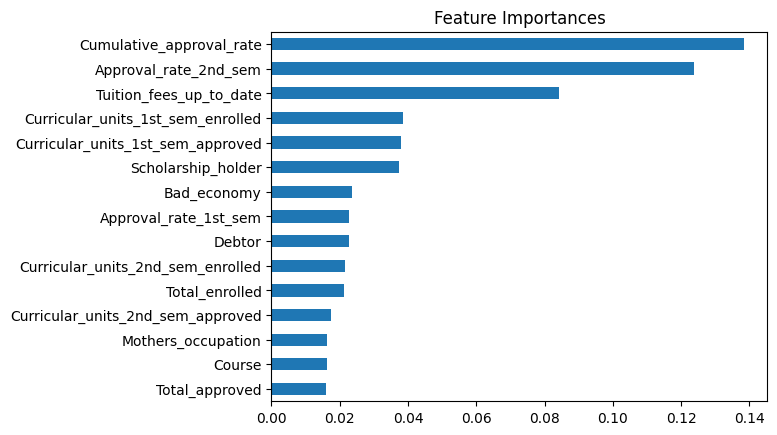

In [130]:
importance = pd.Series(xgb.feature_importances_, index=X.columns)
importance = importance.sort_values(ascending=False)

importance.head(15).plot(kind='barh')
plt.title('Feature Importances')
plt.gca().invert_yaxis()
plt.show()